# LangGraph 기초: 조건부 엣지(Conditional Edges)

## 학습 목표
- **조건부 엣지(Conditional Edges)** 개념 이해
- `add_conditional_edges()` 메서드 사용법 학습
- 상태 기반 분기(branching) 로직 구현
- 단순 분기(날씨)와 복잡한 분기(의도 기반 라우팅) 두 가지 예제 학습

## 핵심 개념
- **조건 함수(condition function)**: 현재 상태를 분석하고 문자열 키를 반환하여 어느 노드로 갈지 결정
- **라우팅 맵(routing map)**: 조건 함수의 반환값을 실제 노드명에 매핑
- **분기**: START → 노드 → 조건부 엣지 → 여러 노드 중 하나로 → END

In [1]:
# pip install -U langgraph

## 예제 1 - 랜덤 날씨 분기

### 예제 개요
- 목적: 가장 간단한 조건부 엣지 예제
- 흐름: START -> weather(기본 인사) -> forecast_weather(조건 함수) -> rainy 또는 sunny -> END
- 핵심: 조건 함수가 반환하는 문자열에 따라 두 가지 경로 중 하나로 분기

### 1. 라이브러리 가져오기

LangGraph의 핵심 클래스와 타입을 import 합니다.

In [2]:
# 기본 임포트
from typing import TypedDict
import random
from langgraph.graph import StateGraph, START, END

### 2. State 정의

- message: 누적된 안내 메세지
- weather_type: 최종 날씨 유형("rainy" 또는 "sunny")

In [3]:
# weatherstate 정의
class WeatherState(TypedDict):
    message: str # 안내/응답 문구를 담는 문자열
    weather_type: str # 분기 결과 ('rainy' 또는 'sunny')

### 3. Node 정의

In [4]:

# 노드 함수 1: 기본 안내 메시지 생성
def weather(state: WeatherState) -> WeatherState:
    """날씨 문의의 기본 인사말을 생성합니다."""
    prefix = "Hi! Well... I have no idea... But... "
    base = state.get("message", "")
    combined = (prefix + base).strip()
    return {"message": combined, "weather_type": ""}

# 노드 함수 2: 비 오는 날씨 응답
def rainy_weather(state: WeatherState) -> WeatherState:
    """비 오는 날씨에 대한 안내를 추가합니다."""
    return {
        "message": state["message"] + " It's going to rain today. Carry an umbrella.",
        "weather_type": "rainy",
    }

# 노드 함수 3: 맑은 날씨 응답
def sunny_weather(state: WeatherState) -> WeatherState:
    """맑은 날씨에 대한 안내를 추가합니다."""
    return {
        "message": state["message"] + " It's going to be sunny today. Wear sunscreen.",
        "weather_type": "sunny",
    }

# 조건 함수 — 반환값은 라우팅 맵의 "키"일 뿐
def forecast_weather(state: WeatherState) -> str:
    """
    상태를 분석하여 다음 노드를 결정하는 조건 함수입니다.
    반환값이 라우팅 맵의 키가 되어 어느 노드로 갈지 결정됩니다.
    """
    return "option_a" if random.random() < 0.5 else "option_b"

### 4. Graph 구성 및 조건부 Edge

노드를 등록하고 엣지로 연결합니다. add_conditional_edges()로 조건부 분기를 설정합니다.

In [5]:
# 그래프 생성 및 노드 등록
workflow = StateGraph(WeatherState)
workflow.add_node("weather", weather)
workflow.add_node("rainy", rainy_weather)
workflow.add_node("sunny", sunny_weather)

# 엣지 연결
# START에서 weather 노드로 이동
workflow.add_edge(START, "weather")

# weather 노드에서 조건 함수 forecast_weather를 실행
# - 함수가 "option_a"를 반환하면 "rainy_node" 노드로 이동
# - 함수가 "option_b"를 반환하면 "sunny_node" 노드로 이동
workflow.add_conditional_edges(
    "weather",
    forecast_weather,
    {
        "option_a": "rainy",    # 키 "option_a" → 노드 "rainy"로 이동
        "option_b": "sunny",    # 키 "option_b" → 노드 "sunny"로 이동
    },
)

# 종료 엣지: rainy와 sunny 노드 다음은 모두 END
workflow.add_edge("rainy", END)
workflow.add_edge("sunny", END)

### 5. 컴파일 및 시각화

그래프를 컴파일하고 구조를 시각화합니다.

In [6]:
# 그래프 컴파일
app = workflow.compile()

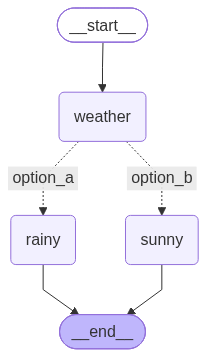

In [7]:
# 그래프로 시각화
from IPython.display import Image, display

png = app.get_graph().draw_mermaid_png()
display(Image(png))

### 6. 실행 예시

여러 초기 상태를 가지고 그래프를 실행합니다.

In [8]:
# 실행 예시 1: 빈 초기 상태
# - message가 비어있고, weather_type을 초기화합니다.
# - weather 노드가 기본 인사말을 생성한 후,
#   조건 함수에 의해 rainy 또는 sunny 중 하나로 분기됩니다.

initial_state = {"message": "", "weather_type": ""}
result1 = app.invoke(initial_state)
print("결과1: ", result1)
print()

결과1:  {'message': "Hi! Well... I have no idea... But... It's going to be sunny today. Wear sunscreen.", 'weather_type': 'sunny'}



In [9]:
# 실행 예시 2: 사용자 메시지가 있는 초기 상태
# - message에 사용자의 질문이 포함되어 있습니다.
# - weather 노드가 기본 인사말과 함께 사용자 메시지를 추가합니다.

initial_state2 = {"message": "What does the weather look like?", "weather_type": ""}
result2 = app.invoke(initial_state2)
print("결과2: ", result2)
print()

결과2:  {'message': "Hi! Well... I have no idea... But... What does the weather look like? It's going to be sunny today. Wear sunscreen.", 'weather_type': 'sunny'}



In [10]:
# 실행 예시 3: 무작위 메시지
# - 날씨와 관계없는 질문을 해도,
#   항상 날씨 응답(rainy 또는 sunny)으로 분기됩니다.
# - LangGraph는 조건 함수의 반환값에만 의존합니다.

initial_state3 = {"message": "How much is 2+2?", "weather_type": ""}
result3 = app.invoke(initial_state3)
print("결과3: ", result3)

결과3:  {'message': "Hi! Well... I have no idea... But... How much is 2+2? It's going to rain today. Carry an umbrella.", 'weather_type': 'rainy'}


## 예제2 - 의도 분석 기반 라우팅

### 예제 개요
더 실전적인 예제로, 사용자 입력을 분석하여 최적의 응답 방식을 선택합니다.

**흐름**:
1. `analyze_intent`: 사용자 메시지를 분석하여 의도 파악
2. `determine_response_type`: 의도에 따라 응답 방식 결정
3. 조건부 엣지로 세 가지 응답 노드 중 하나 선택
   - `respond_simple`: 인사/시간 → 즉시 반환
   - `respond_weather`: 날씨 → 데모 응답
   - `respond_llm`: 일반 질문 → LLM 활용(옵션)
4. 최종 답변 반환

### 핵심 개념
- 다단계 분석: 분류 → 라우팅 → 응답
- 다중 분기: 조건 함수가 3개 이상의 경로를 결정
- 메시지 누적: `add_messages` 활용으로 대화 히스토리 유지

### 1. 라이브러리 가져오고 환경변수 설정

예제2에서 필요한 모든 import와 State 클래스를 정의합니다.

In [23]:
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from dotenv import load_dotenv
import os
from datetime import datetime

# 환경 설정 및 LLM 초기화
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

# LLM 준비(옵션): 키가 없으면 None으로 두고 안전하게 대체
llm = None
try:
    if api_key:
        llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
except Exception:
    llm = None

print("LLM 초기화 완료. (API 키 여부:", "있음" + ")" if llm else "없음" + ")")

LLM 초기화 완료. (API 키 여부: 있음)


### 2. State 정의

In [25]:
from typing import Annotated

# GraphState 정의
# - messages: 대화 메시지 히스토리 (add_messages로 자동 병합)
# - user_intent: 분석된 사용자 의도 (greeting/weather/time/general)
# - response_type: 실행할 응답 유형 (simple/weather/llm)
# - final_answer: 최종 답변 텍스트

class GraphState(TypedDict):
    messages: Annotated[list, add_messages] # 메세지 자동 누적
    user_intent: str # 파악된 사용자 의도
    response_type: str # 결정된 응답 유형
    final_answer: str # 최종 답변

### 3. Node 정의

1단계: 의도 분석 -> 2단계: 응답 타입 결정 -> 3단계: 응답 생성

In [26]:
# 노드 함수 1: 사용자 의도 분석
def analyze_intent(state: GraphState) -> GraphState:
    """
    사용자의 마지막 메시지를 분석하여 의도를 파악합니다.
    의도: greeting(인사), weather(날씨), time(시간), general(일반 질문)
    """
    messages = state.get("messages", [])
    last = messages[-1].content if messages else ""

    # 간단한 규칙 기반 분류
    if "안녕" in last or "hello" in last.lower(): # lower을 통해서 소문자로 통일한 뒤 비교
        intent = "greeting"
    elif "날씨" in last or "weather" in last.lower():
        intent = "weather"
    elif "시간" in last or "time" in last.lower():
        intent = "time"
    else:
        intent = "general"

    return {"user_intent": intent}

# 노드 함수 2: 응답 타입 결정
def determine_response_type(state: GraphState) -> GraphState:
    """
    파악된 의도(user_intent)에 따라 응답 타입을 결정합니다.
    이 반환값이 조건 함수의 기반이 됩니다.
    """
    intent = state.get("user_intent", "general")

    # 의도 -> 응답 타입 매핑
    if intent in ["greeting", "time"]:
        rtype = "simple"
    elif intent == "weather":
        rtype = "weather"
    else:
        rtype = "llm"

    return {"response_type": rtype}

In [27]:
# 노드 함수 3: 간단 응답 생성 (simple)
def respond_simple(state: GraphState) -> GraphState:
    """
    인사(greeting) 또는 시간(time) 요청에 대한 간단한 응답을 생성합니다.
    이 응답들은 사전 정의된 템플릿을 사용합니다.
    """
    intent = state.get("user_intent", "general")
    
    if intent == "greeting":
        text = "안녕하세요! 무엇을 도와드릴까요?"
    elif intent == "time":
        # 시스템 시간을 이용하여 현재 시간 반환
        now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        text = f"지금 시간은 {now} 입니다."
    else:
        text = "간단 응답으로 분기되었지만, 추가 정보가 필요합니다."

    return {
        "final_answer": text,
        "messages": [AIMessage(content=text)],  # 응답을 메시지 히스토리에 추가
    }

# 노드 함수 4: 날씨 응답 생성 (weather)
def respond_weather(state: GraphState) -> GraphState:
    """
    날씨 관련 요청에 대한 응답을 생성합니다.
    실제 API는 없으므로, 데모용 응답 중 하나를 선택합니다.
    """
    sample = [
        "오늘은 맑고 따뜻할 예정이에요. 가벼운 겉옷을 추천합니다.",
        "오후에 비가 올 수 있어요. 우산을 챙기세요.",
        "바람이 강하니 외출 시 주의하세요.",
        "구름 많고 선선할 전망이에요.",
    ]
    text = f"[데모] 날씨 안내: {random.choice(sample)}"
    
    return {
        "final_answer": text,
        "messages": [AIMessage(content=text)],  # 응답을 메시지 히스토리에 추가
    }

# 노드 함수 5: LLM 응답 생성 (llm)
def respond_llm(state: GraphState) -> GraphState:
    """
    일반 질문에 대해 LLM을 이용해 응답을 생성합니다.
    OpenAI 키가 없으면 안전한 대체 문자열로 응답합니다.
    """
    messages = state.get("messages", [])
    last = messages[-1].content if messages else ""

    if llm is None:
        # API 키 없을 때의 안전한 대체
        text = f"[데모] LLM 비활성화 상태. 질문: {last}"
    else:
        # LLM 호출
        sys = SystemMessage(content="당신은 간결하고 정확한 한국어 조수입니다. 가능한 한 짧고 명확하게 답하세요.")
        res = llm.invoke([sys, HumanMessage(content=last)])
        text = res.content

    return {
        "final_answer": text,
        "messages": [AIMessage(content=text)],  # 응답을 메시지 히스토리에 추가
    }

In [28]:
# 그래프 생성 및 노드 등록
workflow = StateGraph(WeatherState)
workflow.add_node("weather", weather)
workflow.add_node("rainy", rainy_weather)
workflow.add_node("sunny", sunny_weather)

# 엣지 연결
# START에서 weather 노드로 이동
workflow.add_edge(START, "weather")

# weather 노드에서 조건 함수 forecast_weather를 실행
# - 함수가 "option_a"를 반환하면 "rainy_node" 노드로 이동
# - 함수가 "option_b"를 반환하면 "sunny_node" 노드로 이동
workflow.add_conditional_edges(
    "weather",
    forecast_weather,
    {
        "option_a": "rainy",    # 키 "option_a" → 노드 "rainy"로 이동
        "option_b": "sunny",    # 키 "option_b" → 노드 "sunny"로 이동
    },
)

# 종료 엣지: rainny와 sunny 노드 다음은 모두 END
workflow.add_edge("rainy", END)
workflow.add_edge("sunny", END)

### 4. Graph 구성 및 Edge

노드와 엣지를 연결하여 전체 라우팅 흐름을 구성합니다.

In [29]:
# 워크플로우 생성
workflow2 = StateGraph(GraphState)

# 노드 등록: 분석 → 결정 → 응답(3가지)
workflow2.add_node("analyze_intent", analyze_intent)
workflow2.add_node("determine_response_type", determine_response_type)
workflow2.add_node("respond_simple", respond_simple)
workflow2.add_node("respond_weather", respond_weather)
workflow2.add_node("respond_llm", respond_llm)

# 기본 엣지: START → 분석 → 타입 결정
workflow2.add_edge(START, "analyze_intent")
workflow2.add_edge("analyze_intent", "determine_response_type")

# 조건 함수: response_type에 따라 라우팅
def route_by_type(state: GraphState) -> str:
    """
    determine_response_type 노드 이후, 응답 타입에 따라
    어느 응답 노드로 갈지 결정합니다.
    반환값: "simple", "weather", "llm"
    """
    return state.get("response_type", "llm")

# 조건부 엣지: response_type 값에 따라 3가지 경로 중 선택
workflow2.add_conditional_edges(
    "determine_response_type",  # 이 노드 다음에서 조건을 평가
    route_by_type,               # 라우팅 조건 함수
    {
        "simple": "respond_simple",      # "simple" → 간단 응답 노드
        "weather": "respond_weather",    # "weather" → 날씨 응답 노드
        "llm": "respond_llm",            # "llm" → LLM 응답 노드
        "__else__": "respond_llm",       # 예상 외 값 → LLM으로 기본 처리
    },
)

# 종료 엣지: 모든 응답 노드에서 END로
workflow2.add_edge("respond_simple", END)
workflow2.add_edge("respond_weather", END)
workflow2.add_edge("respond_llm", END)

### 5. 컴파일 및 시각화

In [30]:
# 워크플로우 컴파일
app2 = workflow2.compile()

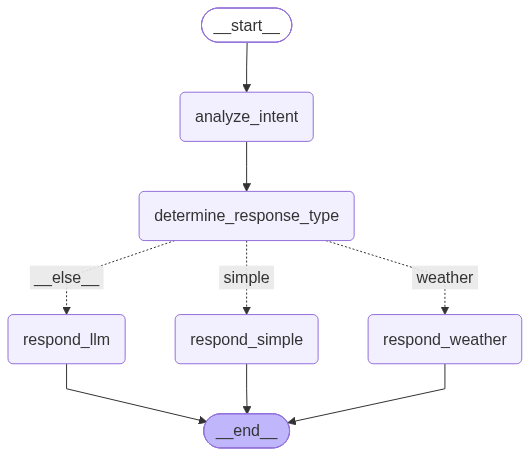

In [31]:
# 그래프 시각화
try:
    png2 = app2.get_graph().draw_mermaid_png()
    display(Image(png2))
except Exception as e:
    print(f"시각화 실패")

### 6. 실행 예시

네가지 다른 의도의 질문으로 라우팅을 확인합니다.

In [32]:
# 실행 예시 1: 인사 -> respond_simple 분기
s1 = {"messages": [HumanMessage(content="Hello!")]}
r1 = app2.invoke(s1)
print("[인사] 의도:", r1.get("user_intent"), "→ 응답 타입:", r1.get("response_type"))
print("최종 답:", r1.get("final_answer"))
print()

[인사] 의도: greeting → 응답 타입: simple
최종 답: 안녕하세요! 무엇을 도와드릴까요?



In [33]:
# 실행 예시 2: 시간 → respond_simple 분기
s2 = {"messages": [HumanMessage(content="지금 시간 알려줘")]} 
r2 = app2.invoke(s2)
print("[시간] 의도:", r2.get("user_intent"), "→ 응답 타입:", r2.get("respond_type"))
print("최종 답:", r2.get("final_answer"))
print()

[시간] 의도: time → 응답 타입: None
최종 답: 지금 시간은 2026-07-30 01:35:55 입니다.



In [34]:
# 실행 예시 3: 날씨 → respond_weather 분기
s3 = {"messages": [HumanMessage(content="오늘 날씨 어때?")]}
r3 = app2.invoke(s3)
print("[날씨] 의도:", r3.get("user_intent"), "→ 응답 타입:", r3.get("response_type"))
print("최종 답:", r3.get("final_answer"))
print()

[날씨] 의도: weather → 응답 타입: weather
최종 답: [데모] 날씨 안내: 구름 많고 선선할 전망이에요.



In [35]:
# 실행 예시 4: 일반 질문 → respond_llm 분기
s4 = {"messages": [HumanMessage(content="LangGraph는 어떤 점이 좋아?")]}
r4 = app2.invoke(s4)
print("[일반] 의도:", r4.get("user_intent"), "→ 응답 타입:", r4.get("response_type"))
print("최종 답:", r4.get("final_answer"))

[일반] 의도: general → 응답 타입: llm
최종 답: LangGraph는 언어 모델을 기반으로 한 그래프 구조를 활용하여 정보 검색과 자연어 처리의 효율성을 높입니다. 주요 장점은 다음과 같습니다:

1. **정보 연결성**: 다양한 데이터 간의 관계를 시각적으로 표현.
2. **효율적인 검색**: 관련 정보를 빠르게 찾을 수 있음.
3. **유연성**: 다양한 언어와 도메인에 적용 가능.
4. **지식 확장**: 새로운 정보를 쉽게 추가하고 업데이트할 수 있음.

이러한 특성 덕분에 데이터 분석과 의사결정에 유용합니다.


# 핵심 정리

### 조건부 엣지(Conditional Edges)의 세 가지 요소

#### 1. 조건 함수 (Condition Function)
```python
def forecast_weather(state: WeatherState) -> str:
    return "rainy" if random.random() < 0.5 else "sunny"
```
- **역할**: 현재 상태를 분석하고 분기 키(문자열)를 반환
- **입력**: 그래프의 State 객체
- **출력**: 라우팅 맵의 키로 사용될 문자열

#### 2. 라우팅 맵 (Routing Map)
```python
{
    "rainy": "rainy",       # 조건 함수 반환값 → 목적 노드
    "sunny": "sunny",
    "__else__": "default_node"  # 예상 외 값의 기본값
}
```
- **역할**: 조건 함수의 반환값을 실제 노드 이름에 매핑
- **특수 키**: `"__else__"`는 예상 외 반환값의 기본값

#### 3. add_conditional_edges() 메서드
```python
workflow.add_conditional_edges(
    "weather",                  # 조건을 평가할 출발 노드
    forecast_weather,            # 조건 함수
    {"rainy": "rainy", ...}    # 라우팅 맵
)
```
- 노드 다음에서 상태 기반 분기를 정의
- 고정 엣지 `add_edge()`와 달리 동적으로 경로를 결정

### 실무 활용 예시

1. **단순 분기**: 확률 또는 규칙 기반 분기 (예: 날씨)
2. **의도 기반 라우팅**: 자연어 의도 분석 후 다양한 핸들러로 분배
3. **동적 워크플로우**: 중간 결과에 따라 다음 단계 결정
4. **에러 핸들링**: 결과 상태에 따라 재시도 또는 폴백 경로

### 주요 패턴
- **누적 패턴**: `Annotated[list, add_messages]`로 메시지 히스토리 자동 누적
- **명시적 라우팅**: 조건 함수와 라우팅 맵으로 흐름을 명확하게 정의
- **안전한 기본값**: `"__else__"`로 예상 외 상황 처리
- **다단계 분석**: 분석 → 결정 → 실행으로 구조화된 로직
